<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_4/Laboratorio_4_Grafico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np

# Manejo de datos tabulares
import pandas as pd

# Libreria para graficos
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [ ]:
from PIL import Image

ruta_train = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/DevanagariHandwrittenCharacterDataset/Train'
ruta_test  = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/DevanagariHandwrittenCharacterDataset/Test'

imagenes = []
etiquetas = []

clases = sorted(os.listdir(ruta_train))
clase_a_numero = {clase: i for i, clase in enumerate(clases)}

print('Número de clases:', len(clases))
print('Cargando imágenes...')

for carpeta in [ruta_train, ruta_test]:
    for clase in clases:
        ruta_clase = os.path.join(carpeta, clase)
        if not os.path.isdir(ruta_clase):
            continue
        for archivo in os.listdir(ruta_clase):
            ruta_img = os.path.join(ruta_clase, archivo)
            img = Image.open(ruta_img).convert('L')   # escala de grises
            img = img.resize((32, 32))
            imagenes.append(np.array(img).flatten())  # 1024 features
            etiquetas.append(clase_a_numero[clase])

X = np.array(imagenes)
y = np.array(etiquetas)

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Clases únicas:', np.unique(y))

Número de clases: 46
Cargando imágenes...
Shape X: (74904, 1024)
Shape y: (74904,)
Clases únicas: [ 0  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]


In [ ]:
# Ver qué clases se detectaron y cuáles faltan
print('Clases detectadas como carpetas:')
for i, clase in enumerate(clases):
    print(i, '->', clase)

Clases detectadas como carpetas:
0 -> character_10_yna
1 -> character_11_taamatar
2 -> character_12_thaa
3 -> character_13_daa
4 -> character_14_dhaa
5 -> character_15_adna
6 -> character_16_tabala
7 -> character_17_tha
8 -> character_18_da
9 -> character_19_dha
10 -> character_1_ka
11 -> character_20_na
12 -> character_21_pa
13 -> character_22_pha
14 -> character_23_ba
15 -> character_24_bha
16 -> character_25_ma
17 -> character_26_yaw
18 -> character_27_ra
19 -> character_28_la
20 -> character_29_waw
21 -> character_2_kha
22 -> character_30_motosaw
23 -> character_31_petchiryakha
24 -> character_32_patalosaw
25 -> character_33_ha
26 -> character_34_chhya
27 -> character_35_tra
28 -> character_36_gya
29 -> character_3_ga
30 -> character_4_gha
31 -> character_5_kna
32 -> character_6_cha
33 -> character_7_chha
34 -> character_8_ja
35 -> character_9_jha
36 -> digit_0
37 -> digit_1
38 -> digit_2
39 -> digit_3
40 -> digit_4
41 -> digit_5
42 -> digit_6
43 -> digit_7
44 -> digit_8
45 -> digi

In [ ]:
# Reasignar etiquetas 0 a 45 sin huecos
clases_unicas = sorted(np.unique(y))
reasignar = {viejo: nuevo for nuevo, viejo in enumerate(clases_unicas)}
y = np.array([reasignar[etiqueta] for etiqueta in y])

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Clases únicas:', np.unique(y))
print('Número de clases:', len(np.unique(y)))

num_labels = len(np.unique(y))
print('num_labels:', num_labels)

Shape X: (74904, 1024)
Shape y: (74904,)
Clases únicas: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]
Número de clases: 44
num_labels: 44


In [ ]:
print('Distribución de clases:')
clases_unicas, conteos = np.unique(y, return_counts=True)
for c, n in zip(clases_unicas, conteos):
    print('Clase {:2d}: {:5d} ejemplos'.format(c, n))

print('\nMínimo por clase:', conteos.min())
print('Máximo por clase:', conteos.max())
num_labels = 44

Distribución de clases:
Clase  0:  1700 ejemplos
Clase  1:  1700 ejemplos
Clase  2:  1700 ejemplos
Clase  3:  1700 ejemplos
Clase  4:  1700 ejemplos
Clase  5:  1700 ejemplos
Clase  6:  1700 ejemplos
Clase  7:  1700 ejemplos
Clase  8:  1700 ejemplos
Clase  9:  1700 ejemplos
Clase 10:  1716 ejemplos
Clase 11:   888 ejemplos
Clase 12:  1700 ejemplos
Clase 13:  1700 ejemplos
Clase 14:  1700 ejemplos
Clase 15:  1700 ejemplos
Clase 16:  1700 ejemplos
Clase 17:  1700 ejemplos
Clase 18:  1700 ejemplos
Clase 19:  1700 ejemplos
Clase 20:  1700 ejemplos
Clase 21:  1700 ejemplos
Clase 22:  1700 ejemplos
Clase 23:  1700 ejemplos
Clase 24:  1700 ejemplos
Clase 25:  1700 ejemplos
Clase 26:  1700 ejemplos
Clase 27:  1700 ejemplos
Clase 28:  1700 ejemplos
Clase 29:  1700 ejemplos
Clase 30:  1700 ejemplos
Clase 31:  1700 ejemplos
Clase 32:  1700 ejemplos
Clase 33:  1700 ejemplos
Clase 34:  1700 ejemplos
Clase 35:  1700 ejemplos
Clase 36:  1700 ejemplos
Clase 37:  1700 ejemplos
Clase 38:  1700 ejemplos
C

In [ ]:
# Balancear tomando 888 ejemplos por clase (el mínimo)
np.random.seed(42)
indices_balanceados = []

for c in range(num_labels):
    idx = np.where(y == c)[0]
    idx_muestra = np.random.choice(idx, 888, replace=False)
    indices_balanceados.append(idx_muestra)

indices_balanceados = np.concatenate(indices_balanceados)
np.random.shuffle(indices_balanceados)

X = X[indices_balanceados]
y = y[indices_balanceados]

print('Shape X balanceado:', X.shape)
print('Shape y balanceado:', y.shape)
print('Ejemplos por clase:', np.unique(y, return_counts=True)[1])
print('Total ejemplos:', len(y))

Shape X balanceado: (39072, 1024)
Shape y balanceado: (39072,)
Ejemplos por clase: [888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888
 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888 888
 888 888 888 888 888 888 888 888]
Total ejemplos: 39072


In [ ]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X_norm[0, :])
print(y)

[0. 0. 0. ... 0. 0. 0.]
[21  2 41 ... 32 41 15]


In [ ]:
# Configurar la matriz adecuadamente
m, n = X.shape

# División 80/20 con semilla fija para reproducibilidad
np.random.seed(42)
indices = np.random.permutation(m)
corte   = int(0.8 * m)

# Normalizar solo con datos de entrenamiento
X_train_raw = X[indices[:corte]]
y_train     = y[indices[:corte]]
X_test_raw  = X[indices[corte:]]
y_test      = y[indices[corte:]]

X_train_norm, mu, sigma = featureNormalize(X_train_raw)
X_test_norm  = (X_test_raw - mu) / sigma

# X e y apuntan al conjunto de entrenamiento
X = X_train_norm
y = y_train

print(X_train_norm[0, :])
print(y_train)
print('Ejemplos entrenamiento (80%):', X_train_norm.shape[0])
print('Ejemplos prueba       (20%):', X_test_norm.shape[0])

[0. 0. 0. ... 0. 0. 0.]
[ 7 12  2 ... 22 10  7]
Ejemplos entrenamiento (80%): 31257
Ejemplos prueba       (20%): 7815


In [ ]:
def sigmoid(z):
    """
    Calcula la sigmoide de z.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

In [ ]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Calcula el costo de usar theta como parámetro para la regresión logística regularizada y
    el gradiente del costo w.r.t. a los parámetros.

    Parametros
    ----------
    theta : array_like
        Parametro theta de la regresion logistica. Vector de la forma(shape) (n, ). n es el numero de caracteristicas
        incluida la intercepcion

    X : array_like
        Dataset con la forma(shape) (m x n). m es el numero de ejemplos, y n es el numero de
        caracteristicas (incluida la intercepcion).

    y : array_like
        El conjunto de etiquetas. Un vector con la forma (shape) (m, ). m es el numero de ejemplos

    lambda_ : float
        Parametro de regularización.

    Devuelve
    -------
    J : float
        El valor calculado para la funcion de costo regularizada.

    grad : array_like
        Un vector de la forma (shape) (n, ) que es el gradiente de la
        función de costo con respecto a theta, en los valores actuales de theta.
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta.copy()
    temp[0] = 0

    h = np.clip(h, 1e-10, 1 - 1e-10)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) \
        + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    """
    Trains num_labels logistic regression classifiers and returns
    each of these classifiers in a matrix all_theta, where the i-th
    row of all_theta corresponds to the classifier for label i.

    Parameters
    ----------
    X : array_like
        The input dataset of shape (m x n).

    y : array_like
        The data labels. A vector of shape (m, ).

    num_labels : int
        Number of possible labels.

    lambda_ : float
        The logistic regularization parameter.

    Returns
    -------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1).
    """
    m, n = X.shape

    all_theta    = np.zeros((num_labels, n + 1))
    cost_history = []

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        costos_clase  = []

        def callback(theta):
            J, _ = lrCostFunction(theta, X, (y == c).astype(int), lambda_)
            costos_clase.append(J)

        options = {'maxiter': 100}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                callback=callback,
                                options=options)

        all_theta[c] = res.x
        cost_history.append(costos_clase)

    return all_theta, cost_history

In [ ]:
lambda_ = 0.1
all_theta, cost_history = oneVsAll(X, y, num_labels, lambda_)
print(all_theta.shape)

(44, 1025)


In [ ]:
print(all_theta)

[[-10.52037799   0.           0.         ...   0.           0.
    0.        ]
 [-11.9276771    0.           0.         ...   0.           0.
    0.        ]
 [ -8.76924813   0.           0.         ...   0.           0.
    0.        ]
 ...
 [-17.01789736   0.           0.         ...   0.           0.
    0.        ]
 [-18.41808542   0.           0.         ...   0.           0.
    0.        ]
 [-12.86238568   0.           0.         ...   0.           0.
    0.        ]]


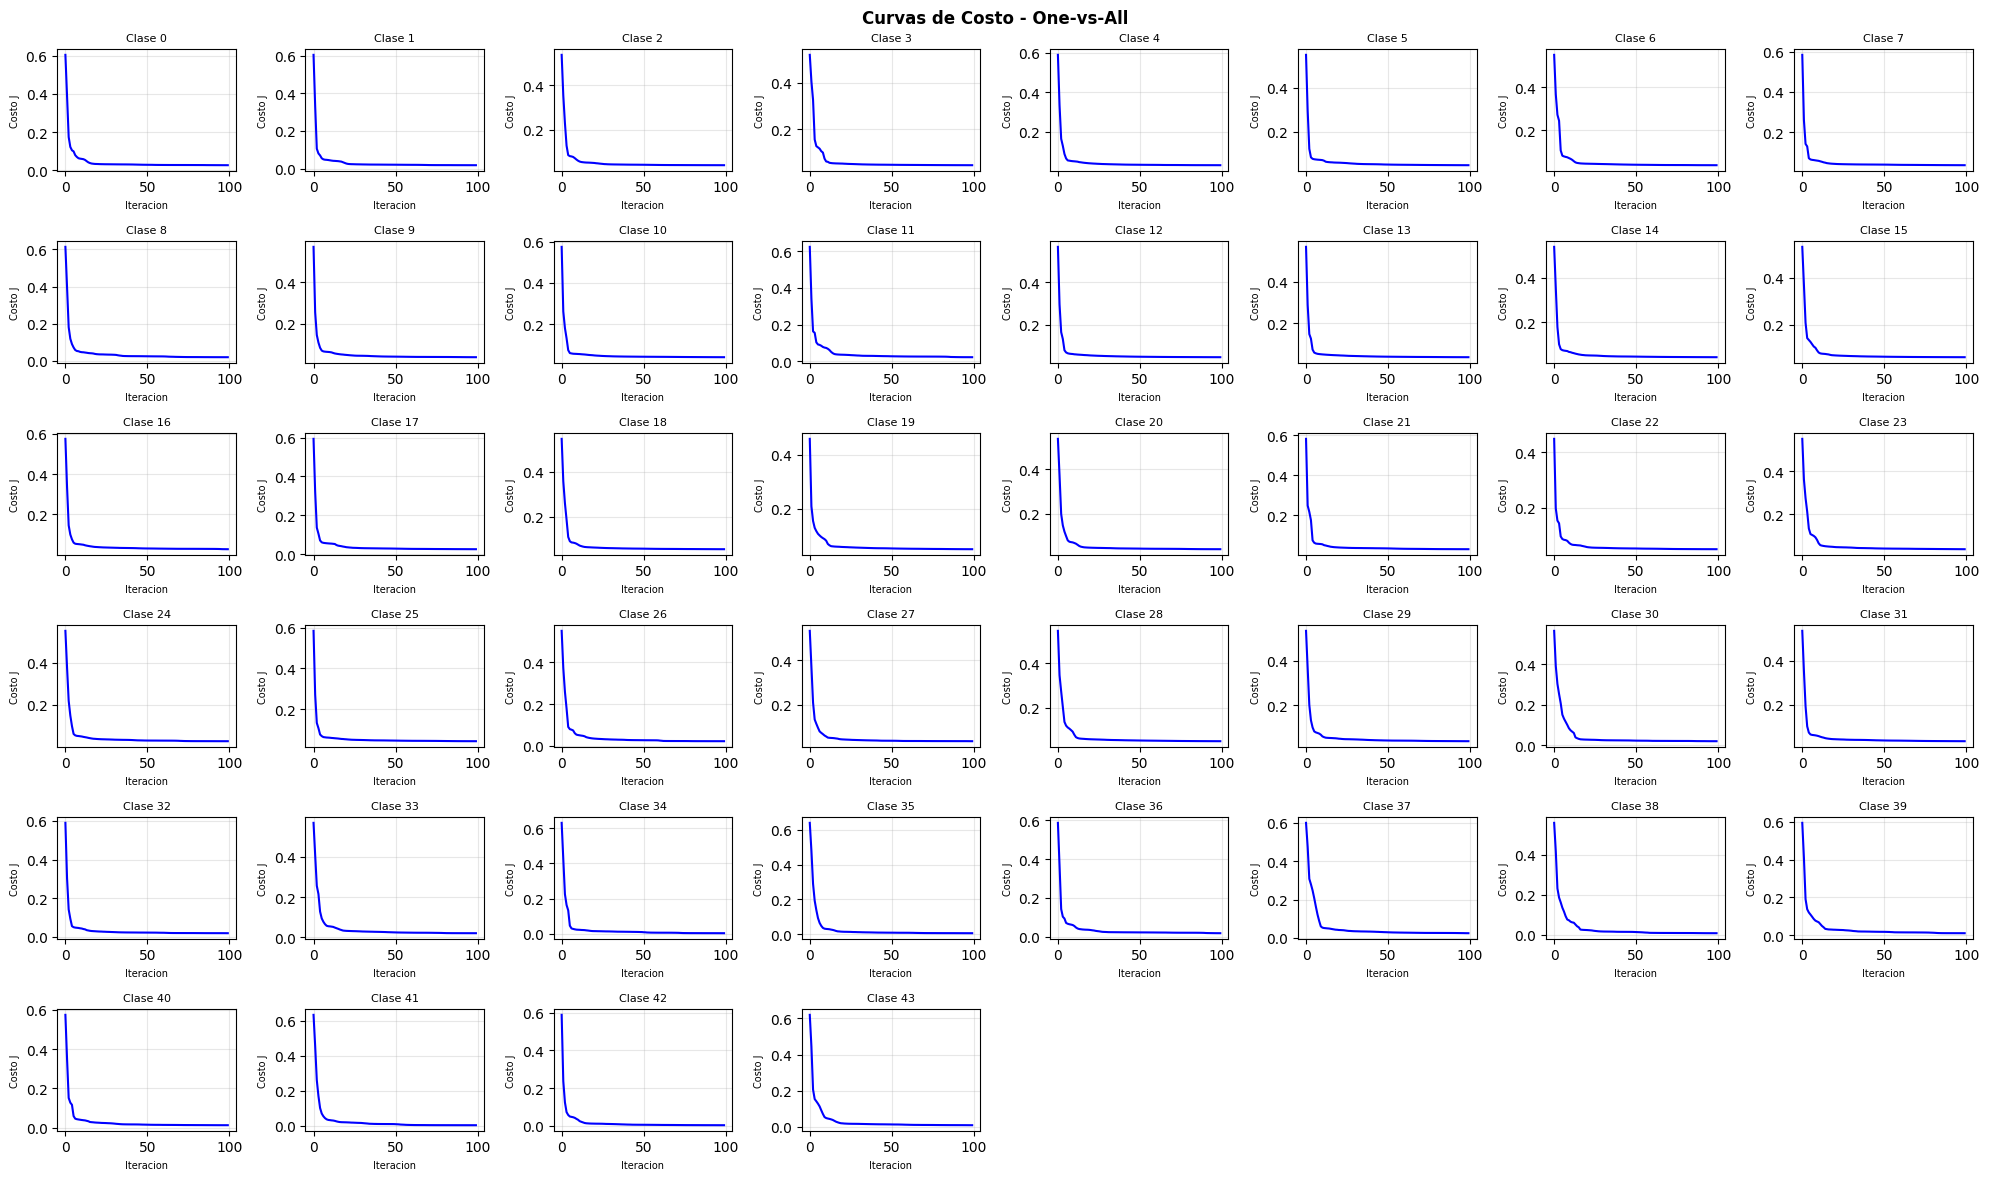

In [ ]:
fig, axes = pyplot.subplots(6, 8, figsize=(20, 12))
axes = axes.flatten()

for c in range(num_labels):
    axes[c].plot(cost_history[c], 'b-', linewidth=1.5)
    axes[c].set_title('Clase {}'.format(c), fontsize=8)
    axes[c].set_xlabel('Iteracion', fontsize=7)
    axes[c].set_ylabel('Costo J', fontsize=7)
    axes[c].grid(True, alpha=0.3)

# Ocultar subplots sobrantes
for c in range(num_labels, len(axes)):
    axes[c].set_visible(False)

pyplot.suptitle('Curvas de Costo - One-vs-All', fontweight='bold')
pyplot.tight_layout()
pyplot.show()

In [ ]:
def predictOneVsAll(all_theta, X):
    """
    Devuelve un vector de predicciones para cada ejemplo en la matriz X.
    Tenga en cuenta que X contiene los ejemplos en filas.
    all_theta es una matriz donde la i-ésima fila es un vector theta de regresión logística entrenada para la i-ésima clase.
    Debe establecer p en un vector de valores de 0..K-1 (por ejemplo, p = [0, 2, 0, 1]
    predice clases 0, 2, 0, 1 para 4 ejemplos).

    Parametros
    ----------
    all_theta : array_like
        The trained parameters for logistic regression for each class.
        This is a matrix of shape (K x n+1).

    X : array_like
        Data points to predict their labels. This is a matrix of shape (m x n).

    Devuelve
    -------
    p : array_like
        The predictions for each data point in X. This is a vector of shape (m, ).
    """
    m = X.shape[0]
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p

In [ ]:
print(X_train_norm.shape)
pred = predictOneVsAll(all_theta, X_train_norm)
print('Precision del conjunto de entrenamiento: {:.2f}%'.format(np.mean(pred == y_train) * 100))

pred_test = predictOneVsAll(all_theta, X_test_norm)
print('Precision del conjunto de prueba (20%):  {:.2f}%'.format(np.mean(pred_test == y_test) * 100))

XPrueba = X_test_norm[100:145, :].copy()
print(XPrueba.shape)

XPrueba = np.concatenate([np.ones((45, 1)), XPrueba], axis=1)
print(XPrueba.shape)

p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)
print(p)

print(y_test[100:145].astype(int))

(31257, 1024)
Precision del conjunto de entrenamiento: 83.01%
Precision del conjunto de prueba (20%):  65.73%
(45, 1024)
(45, 1025)
[38  9 40 21 36  3  4 18 40 26 37 21 17 18 34 42 32  3 12 27 11  4 21 27
 26 41 42  1 20 28 35 13 25  9 14 18 28 14 27 27 42 32 24 30 27]
[38  9 40 21 36  3  4 37 40 26 37 21 17 18 34  6 32  3 12  3 15 14 21 27
 22 41 42  1 20  3 35  9  2 14 14  1 31  4 14 16 42 32 24 30 27]


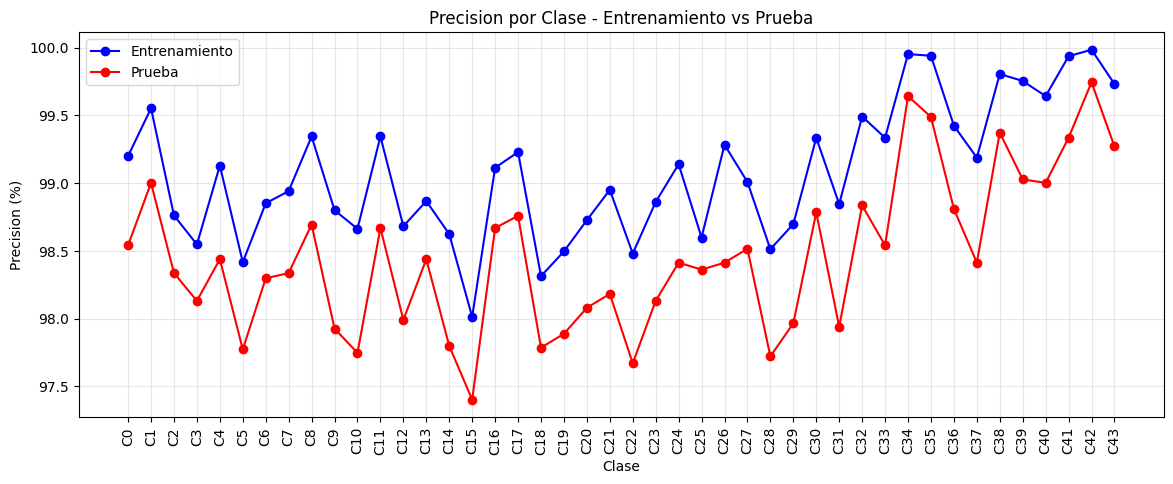

In [ ]:
precisiones_train = []
precisiones_test  = []

X_train_b = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_b  = np.concatenate([np.ones((X_test_norm.shape[0],  1)), X_test_norm],  axis=1)

for c in range(num_labels):
    p_tr = (sigmoid(X_train_b.dot(all_theta[c])) >= 0.5).astype(int)
    p_te = (sigmoid(X_test_b.dot(all_theta[c]))  >= 0.5).astype(int)
    precisiones_train.append(np.mean(p_tr == (y_train == c).astype(int)) * 100)
    precisiones_test.append(np.mean(p_te  == (y_test  == c).astype(int)) * 100)

pyplot.figure(figsize=(14, 5))
pyplot.plot(range(num_labels), precisiones_train, 'bo-', label='Entrenamiento')
pyplot.plot(range(num_labels), precisiones_test,  'ro-', label='Prueba')
pyplot.xlabel('Clase')
pyplot.ylabel('Precision (%)')
pyplot.title('Precision por Clase - Entrenamiento vs Prueba')
pyplot.xticks(range(num_labels), ['C{}'.format(c) for c in range(num_labels)], rotation=90)
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.show()

In [ ]:
# Selecciona aleatoriamente 100 ejemplos del conjunto de prueba
rand_indices = np.random.choice(len(y_test), 100, replace=False)
XPruebaV = X_test_norm[rand_indices, :].copy()

XPrueba100 = np.concatenate([np.ones((100, 1)), XPruebaV], axis=1)
p100 = np.argmax(sigmoid(XPrueba100.dot(all_theta.T)), axis=1)

print('Predicciones:', p100)
print('Reales:      ', y_test[rand_indices].astype(int))
print('Precision en muestra: {:.2f}%'.format(np.mean(p100 == y_test[rand_indices]) * 100))

Predicciones: [30 35 41 18 37 42 11 10 42  6 15 16 30 10 21 40  0 30 13 39 23 32 18 22
 26 24 32 34 16 41  2 28  9 43  2 38 29 42 16  3 23 21 21 14 10  7 24 19
 17 36 34 27 10 14  6  5  5 33 34 25 40 19 30 12 36 27 37  8 43  3 10 14
 38 27 25 11 20 23 23 20  6  6 34 28  9  9 10 21 25 33 27 28 33 10 32  1
 12 37 21  9]
Reales:       [30 35 41 25 37 42 11 10 42  6 15 16 30 10  5 40 26 30 13 39 23 32 40 22
 26 24 32 34 16 41 42  5 20  2  2 38 29 42 16  3 23 13 21 22 29  7 24 22
 17 40 34 27 10 14  6 10 20 33 34 31 40 19 30 12 36 27 37 41 43  3 10 14
 38 27 25 11 20 14 23 24  6  6 34 28 18  9 13 21 25 24 27 28 33 10 32  2
  2 37 19 19]
Precision en muestra: 74.00%


(100, 1024)
(100, 1025)
[ 3 28 28 35  9 15 34 17  2  0 23 33 41 37 33 39 15 30 41 33  1 22  3 22
 12 40 39 19 27 42  8 28 21 17  8  0 17 11  6 36  8 30 35 13 43 30 34 22
 40 32 33 33 19 32 37 20 23 17 30 35 13  6 37 19  2 10 12  2 15  5 18 29
 13 25  9  7 13 15 20 23 42 22 30  7 19 20 21 11 30 19 29 18 42 11 42 27
 14 31 29 43] [ 3 28 10 35  9 22 34 17 32 31 23 33 41 37 33 39  5 30 41 33  1  0 10 20
 12 40 39 19 27 42  8 28 19 17  8  0  4  8  6 36 29 38 35 13 43 30 34 20
 40 32 11 33 19 32 37 20 23 17 30 35 30  6 33 33  2 10 12 41  5 21  1  6
  9 25  9  7  9 10 20 23 42 22 18  7 19 20 21 11 15 19 39  6 42 11 42 27
 14 28 10  2]


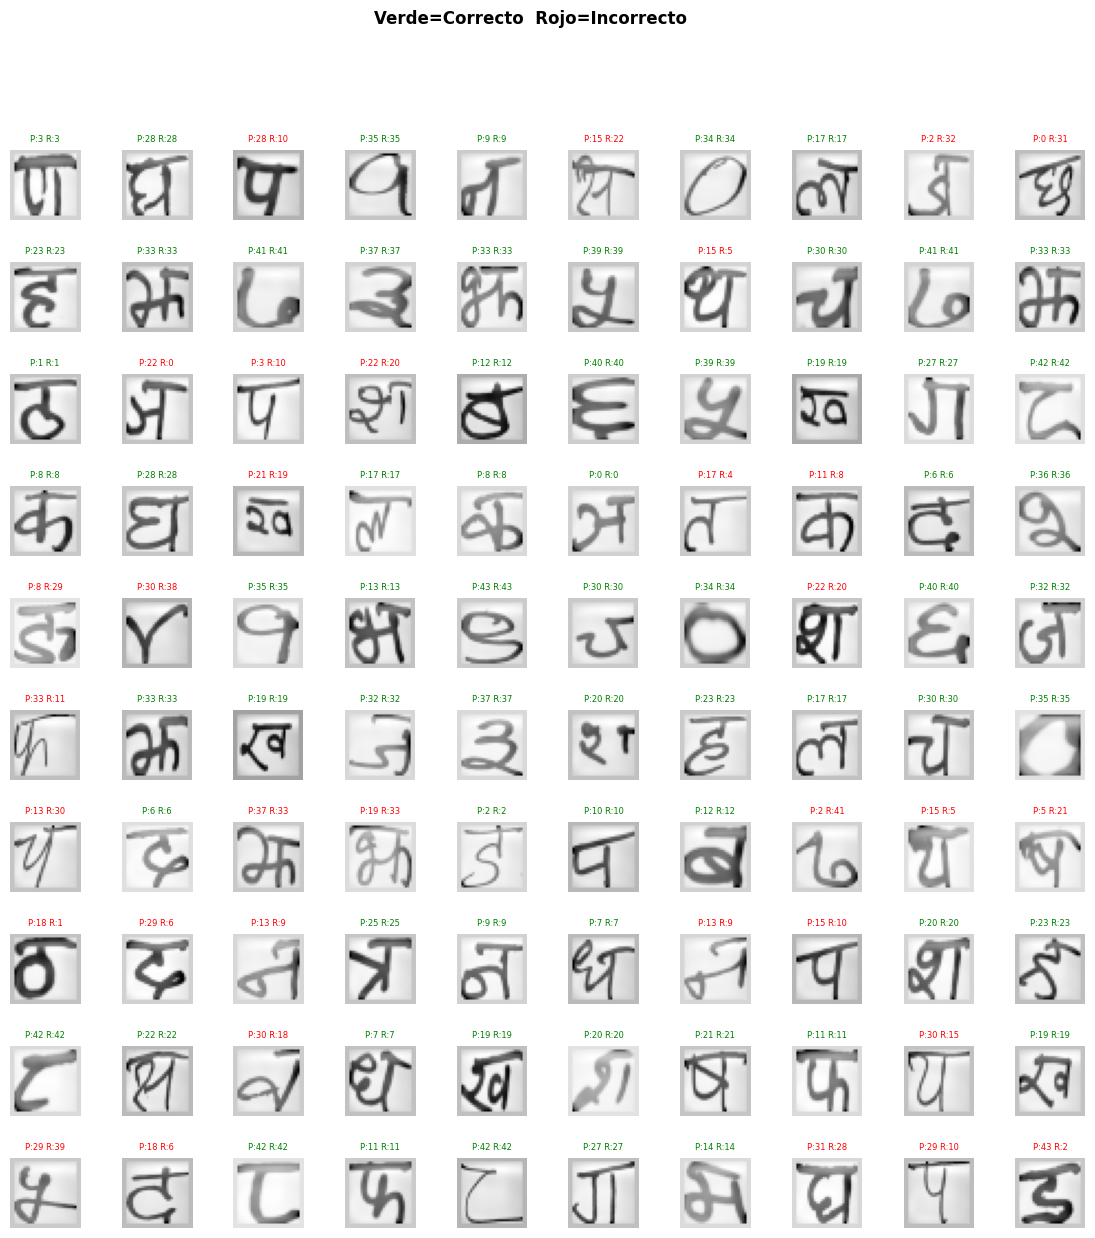

In [ ]:
rand_indices = np.random.choice(len(y_test), 100, replace=False)
XPruebaV = X_test_norm[rand_indices, :].copy()

XPrueba = np.concatenate([np.ones((100, 1)), XPruebaV], axis=1)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

print(XPruebaV.shape)
print(XPrueba.shape)
print(p, y_test[rand_indices])

# Mostrar con etiquetas
fig, ax_array = pyplot.subplots(10, 10, figsize=(14, 14))
fig.subplots_adjust(wspace=0.4, hspace=0.6)
ax_array = ax_array.ravel()

for i, ax in enumerate(ax_array):
    ax.imshow(XPruebaV[i].reshape(32, 32), cmap='Greys')
    real = int(y_test[rand_indices[i]])
    pred_c = int(p[i])
    color = 'green' if real == pred_c else 'red'
    ax.set_title('P:{} R:{}'.format(pred_c, real), fontsize=6, color=color)
    ax.axis('off')

pyplot.suptitle('Verde=Correcto  Rojo=Incorrecto', fontsize=12, fontweight='bold')
pyplot.show()

In [ ]:
# Nombres de las clases en orden
nombres_clases = [
    'ka','kha','ga','gha','kna',
    'cha','chha','ja','jha','yna',
    'taamatar','thaa','daa','dhaa','adna',
    'tabala','tha','da','dha','na',
    'pa','pha','ba','bha','ma',
    'yaw','ra','la','waw','motosaw',
    'petchiryakha','patalosaw','ha','chhya','tra',
    'gya','digit_0','digit_1','digit_2','digit_3',
    'digit_4','digit_5','digit_6','digit_7'
]

print(nombres_clases[0], '->', nombres_clases[43])

ka -> digit_7


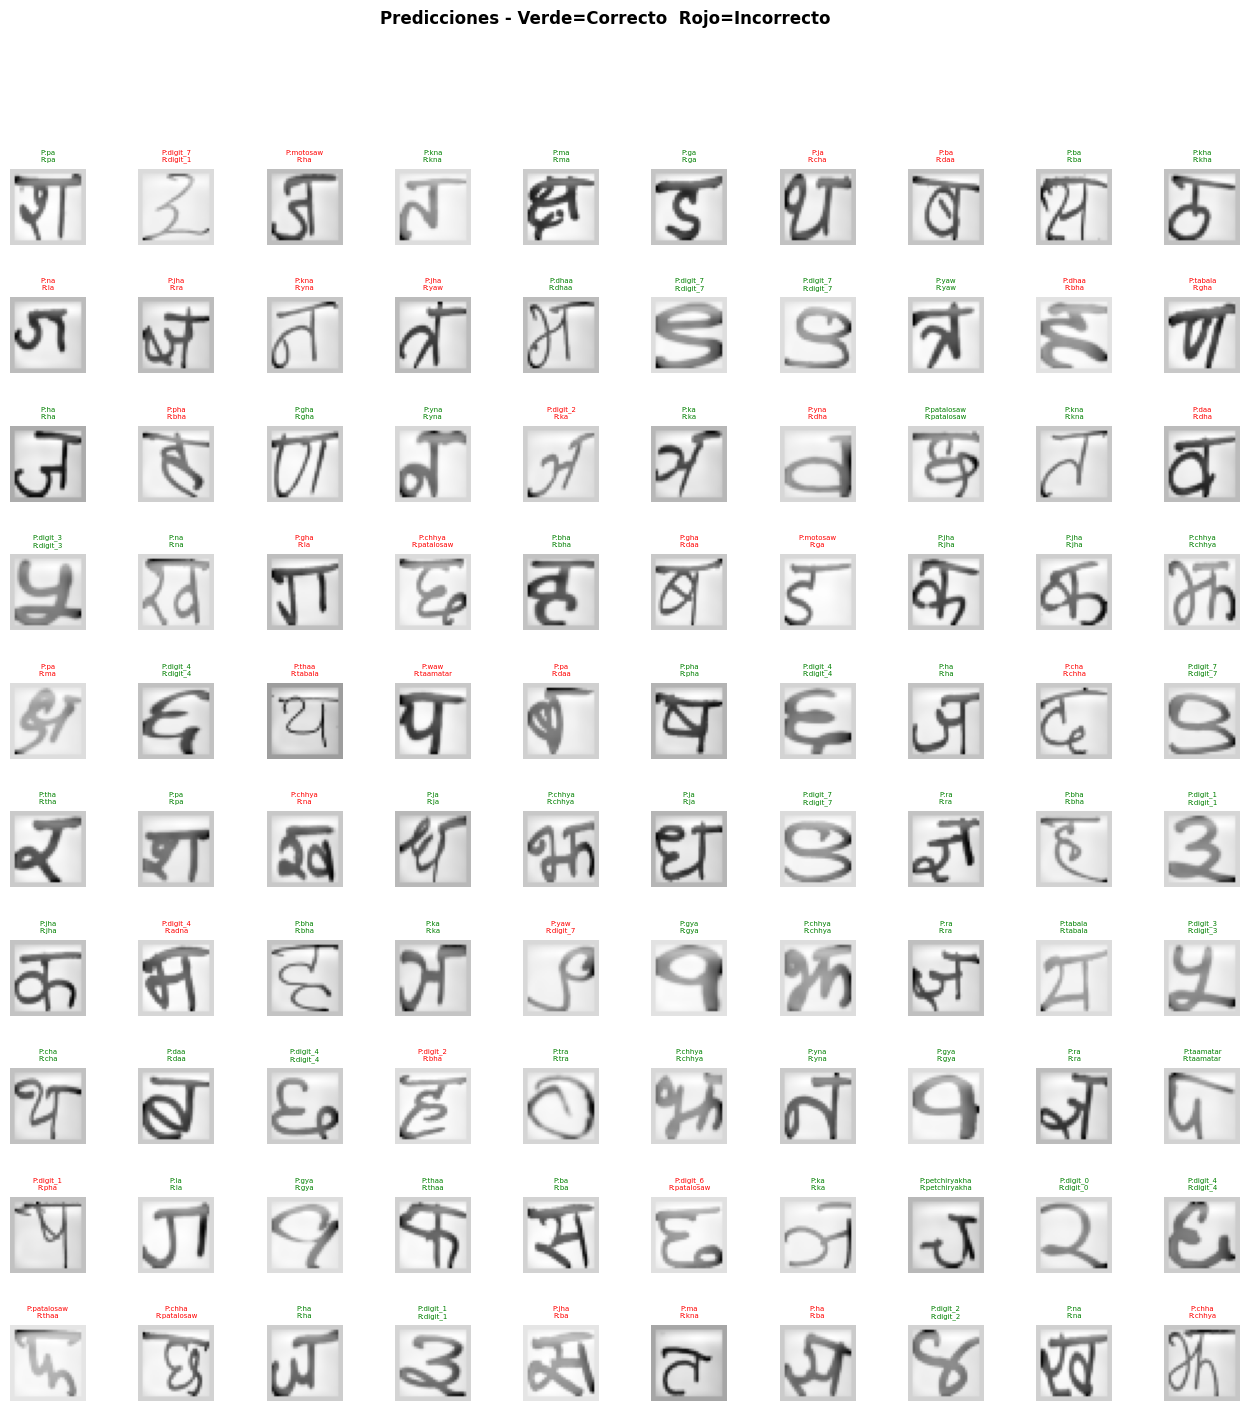

In [ ]:
rand_indices = np.random.choice(len(y_test), 100, replace=False)
XPruebaV = X_test_norm[rand_indices, :].copy()

XPrueba = np.concatenate([np.ones((100, 1)), XPruebaV], axis=1)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

fig, ax_array = pyplot.subplots(10, 10, figsize=(16, 16))
fig.subplots_adjust(wspace=0.5, hspace=0.7)
ax_array = ax_array.ravel()

for i, ax in enumerate(ax_array):
    ax.imshow(XPruebaV[i].reshape(32, 32), cmap='Greys')
    real   = nombres_clases[int(y_test[rand_indices[i]])]
    pred_c = nombres_clases[int(p[i])]
    color  = 'green' if real == pred_c else 'red'
    ax.set_title('P:{}\nR:{}'.format(pred_c, real), fontsize=5, color=color)
    ax.axis('off')

pyplot.suptitle('Predicciones - Verde=Correcto  Rojo=Incorrecto',
                fontsize=12, fontweight='bold')
pyplot.show()

In [ ]:
import matplotlib
import matplotlib.font_manager as fm
import urllib.request

# Descargar fuente que soporta Devanagari
urllib.request.urlretrieve(
    'https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf',
    '/tmp/NotoSansDevanagari.ttf'
)

# Registrar la fuente
fm.fontManager.addfont('/tmp/NotoSansDevanagari.ttf')
matplotlib.rc('font', family='Noto Sans Devanagari')

print('Fuente cargada correctamente')

Fuente cargada correctamente


(100, 1024)
(100, 1025)
[30 30 29 26  5 17 11 41 10 17 30 20  9 22 23 14 26 27 21  6  2  3 31 41
 17 42  7 15 32 24 39 24 20 30 28 26 14 43 34 36  7 20 10 32  2 30 40 24
 17 26 33 19 38 37 35 32  5 28 22 19 11 21 38 12 18 29 18 30  0 33 34 41
  4 13 35 26 41  2 31 15  2 29  1 26  1  1 30 19  9  0 41  7  7 22 21 11
 22 10 10 13] [30  5 29 26 39 17 11 41 28 19 30 26 14 11 23 22 26 27 21  6 10  3 10 41
 17 42  7 15 32 24 39 24 28 30 28 26 14 43 34 36  7 20 10 32  2 30 40 24
 17 26 25  4 13 23 35 32  0 28 22 41 11 21 38 12 18 29 25 30 33 33 34 41
 17 13 35 26 41  2 31 35  2 29  1 30 18  1 30 14  9  0 41  7  7 15 19 16
 22 28 10 33]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 80 (P) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 82 (R) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 114 (r) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarnin

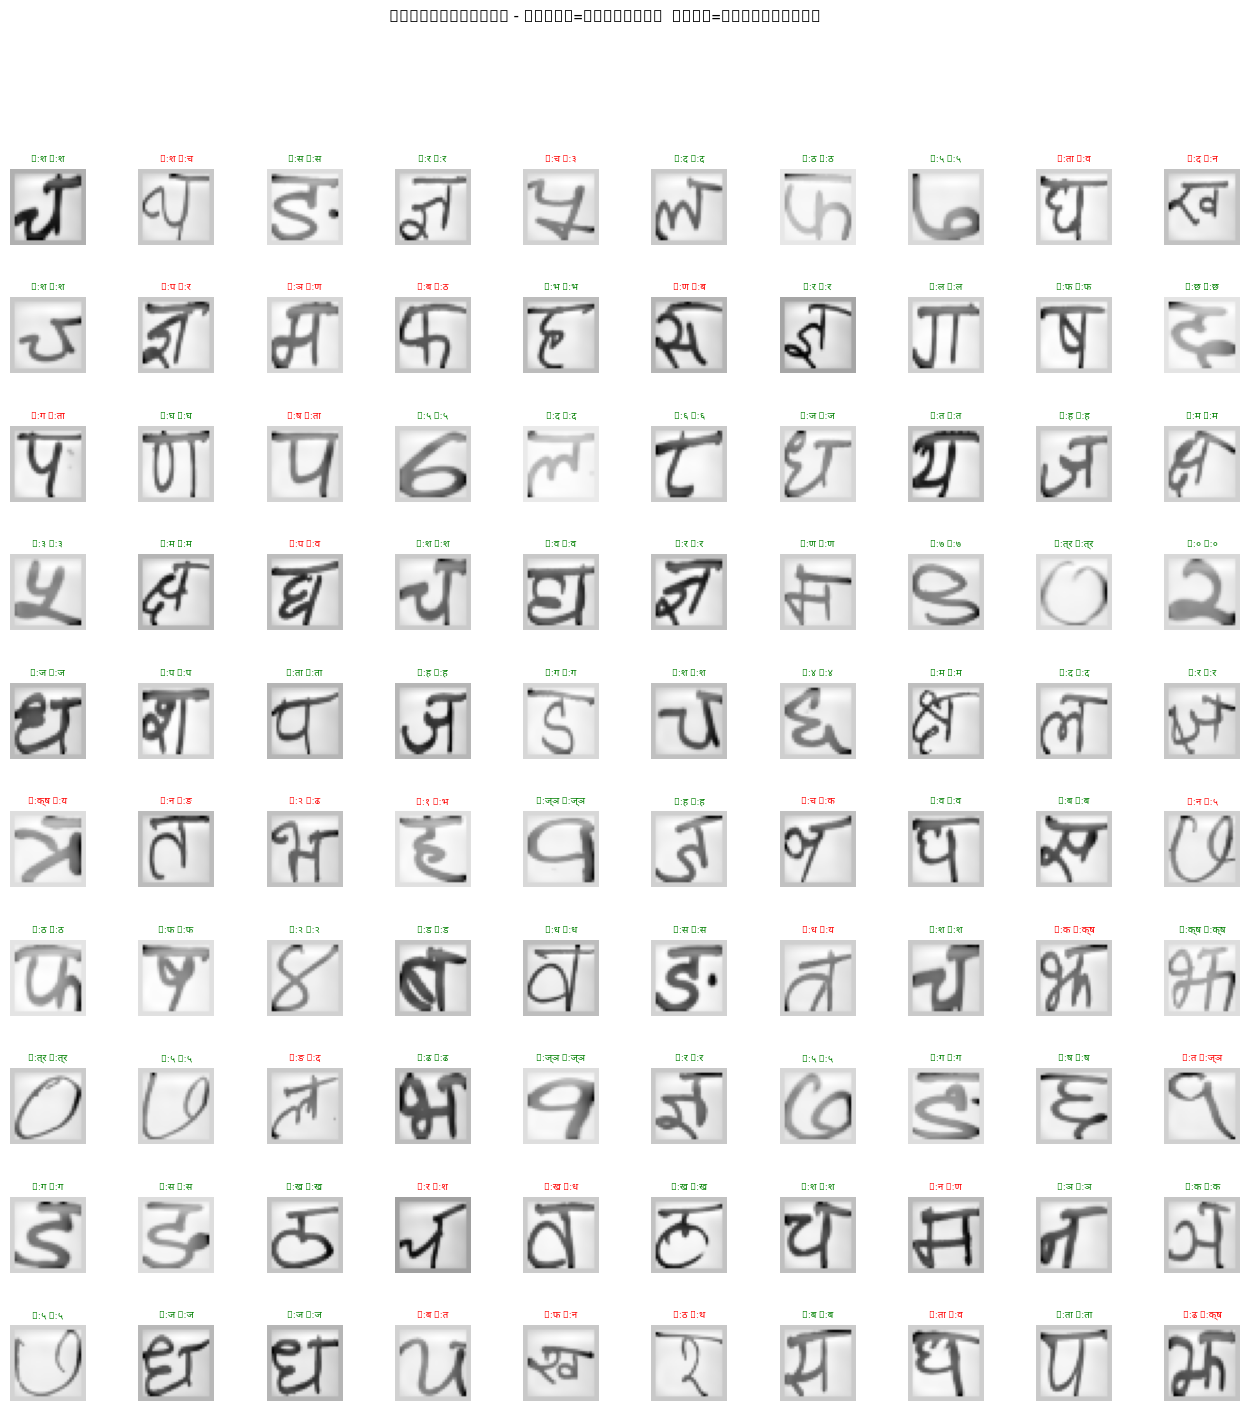

In [ ]:
rand_indices = np.random.choice(len(y_test), 100, replace=False)
XPruebaV = X_test_norm[rand_indices, :].copy()

XPrueba = np.concatenate([np.ones((100, 1)), XPruebaV], axis=1)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

print(XPruebaV.shape)
print(XPrueba.shape)
print(p, y_test[rand_indices])

fig, ax_array = pyplot.subplots(10, 10, figsize=(16, 16))
fig.subplots_adjust(wspace=0.5, hspace=0.7)
ax_array = ax_array.ravel()

for i, ax in enumerate(ax_array):
    ax.imshow(XPruebaV[i].reshape(32, 32), cmap='Greys')
    real   = simbolos_clases[int(y_test[rand_indices[i]])]
    pred_c = simbolos_clases[int(p[i])]
    color  = 'green' if real == pred_c else 'red'
    ax.set_title('P:{} R:{}'.format(pred_c, real), fontsize=7, color=color)
    ax.axis('off')

pyplot.suptitle('Predicciones - Verde=Correcto  Rojo=Incorrecto',
                fontsize=12, fontweight='bold')
pyplot.show()

(100, 1024)
(100, 1025)
[13 16 24 30 16 27  2 42  5 20 25 20 29 23 37  6 27  1 31 10 13 43  4 10
 12 43  6  9 22 14 18 29 40  5 40 35  1 17 34  5  3  5 35 39 39 18 27 39
 42 39  3  9 35  7  2 10 16  6 42 30 22  5  2 18 25 19 42 16 20  6 20 37
 43 38 41 18  2 11 19 24 14 32 23 32  2  3 33 19 29 12 12 31  3 25 13 18
 24  4 19 40] [33  9 30  9 16 16  2 42  0 24 25 20 39 23 37  6  3  1 14 10  7 43  4 10
 12  2 15  9 22 22 12 40 40  5 40 35  1 17 34  5  3 19 21 39 39 18 15 39
 42 39 28  9 35  5 28  7 16 18 42  5 11  5  7 29 25 19 42  4 20  6 20 37
 43 38 41 18 23 11  4 24 14 32 14 32  2 27 33 19  6 12 12 31  3 25 13 18
 14 21  9 40]


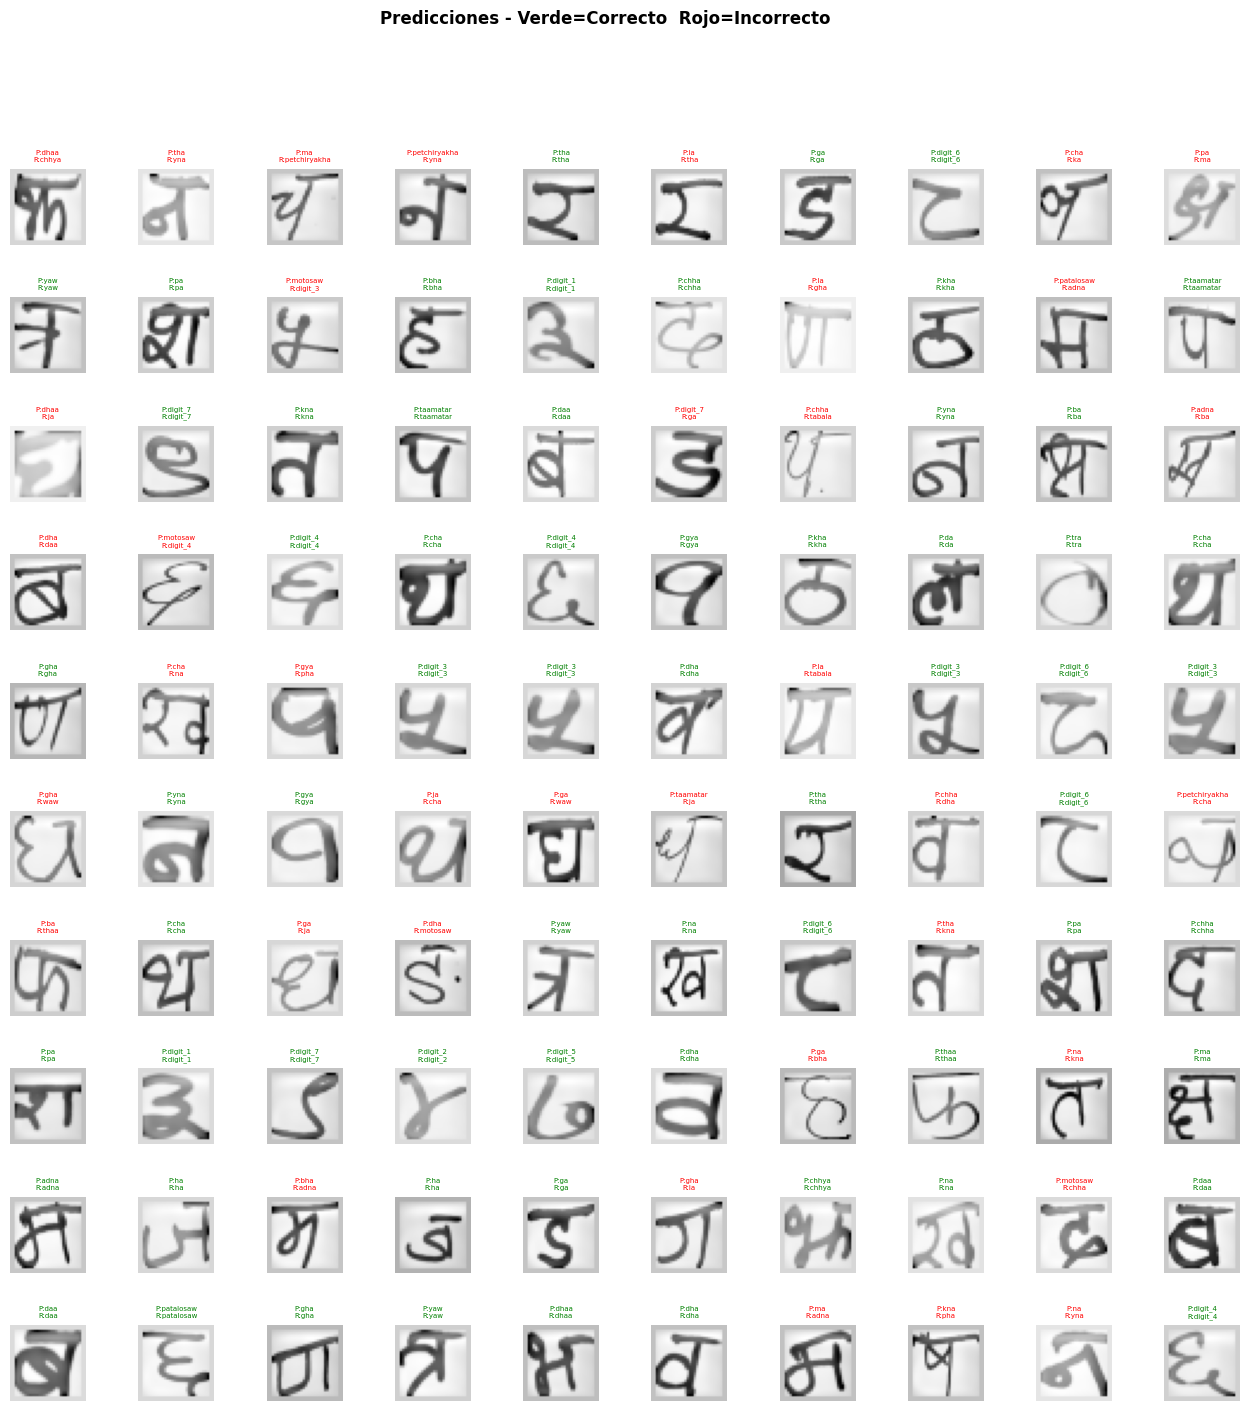

In [ ]:
# Resetear fuente a default
matplotlib.rc('font', family='DejaVu Sans')

rand_indices = np.random.choice(len(y_test), 100, replace=False)
XPruebaV = X_test_norm[rand_indices, :].copy()

XPrueba = np.concatenate([np.ones((100, 1)), XPruebaV], axis=1)
p = np.argmax(sigmoid(XPrueba.dot(all_theta.T)), axis=1)

print(XPruebaV.shape)
print(XPrueba.shape)
print(p, y_test[rand_indices])

fig, ax_array = pyplot.subplots(10, 10, figsize=(16, 16))
fig.subplots_adjust(wspace=0.5, hspace=0.7)
ax_array = ax_array.ravel()

for i, ax in enumerate(ax_array):
    ax.imshow(XPruebaV[i].reshape(32, 32), cmap='Greys')
    real   = nombres_clases[int(y_test[rand_indices[i]])]
    pred_c = nombres_clases[int(p[i])]
    color  = 'green' if real == pred_c else 'red'
    ax.set_title('P:{}\nR:{}'.format(pred_c, real), fontsize=5, color=color)
    ax.axis('off')

pyplot.suptitle('Predicciones - Verde=Correcto  Rojo=Incorrecto',
                fontsize=12, fontweight='bold')
pyplot.show()